### QLLVM Optimization Performance Comparison Test

The following is the comparison result of the optimization capabilities of QLLVM with Qiskit, Qpanda, and PennyLane.

#### 1. Use QLLVM to sequentially compile each test case in the test set, and obtain the compiled qasm files.

In [ ]:
from utils.get_qasm_file import get_qasm_files
import os
qasm_folder = "./MQTBench" 
qasm_files = get_qasm_files(qasm_folder)

for i, qasm_file in enumerate(qasm_files):
    algorithm_name, _ = os.path.splitext(os.path.basename(qasm_file))
    compile_command = f"qllvm {qasm_file} -qrt nisq -qpu qasm-backend -o ./QLLVM/{algorithm_name} -O1 -basicgate=[rx,ry,rz,cz,h]"
    print(f"i: {i} {compile_command}")
    os.system(compile_command)

#### 2. Use Qiskit to sequentially compile each test case in the test set and obtain the compiled qasm files.

In [ ]:
import qiskit
from qiskit import QuantumCircuit,transpile
from utils.get_qasm_file import get_qasm_files
from qiskit_aer import Aer
from qiskit.qasm2 import dumps
import os

qasm_folder = "./MQTBench" 
qasm_files = get_qasm_files(qasm_folder)
for i, qasm_file in enumerate(qasm_files):
    algorithm_name, _ = os.path.splitext(os.path.basename(qasm_file))
    print(f"{qasm_file}")
    qc = qiskit.QuantumCircuit().from_qasm_file(qasm_file)
    transpiled_circuit = transpile(qc,basis_gates=['rx','ry','rz','cz','h'],optimization_level=3)
    qasm_str = dumps(transpiled_circuit)
    compiled_path = f"./Qiskit/{algorithm_name}.qasm"
    with open(compiled_path, "w") as f:
        f.write(qasm_str)

#### 3. Use Qpanda to sequentially compile each test case in the test set and obtain the compiled qasm files.

In [ ]:
from pyqpanda3.core import *
from pyqpanda3.transpilation import Transpiler
from pyqpanda3.intermediate_compiler.intermediate_compiler import convert_qasm_file_to_qprog,convert_qprog_to_qasm
from utils.topo import generate_fully_connected_topology
from utils.get_qasm_file import get_qasm_files
import os

qasm_folder = "./MQTBench" 
qasm_files = get_qasm_files(qasm_folder)
topo = generate_fully_connected_topology(50)

for i, qasm_file in enumerate(qasm_files):
    print(f"{qasm_file}")
    algorithm_name, _ = os.path.splitext(os.path.basename(qasm_file))
    qprog = convert_qasm_file_to_qprog(qasm_file)
    transpiler = Transpiler()
    basic_gates = ['RX','RY','RZ','CZ','H']
    prog_level_3 = transpiler.transpile(qprog, topo, {}, 2,basic_gates)
    qasm_str = convert_qprog_to_qasm(prog_level_3)
    compiled_path = f"./Qpanda/{algorithm_name}.qasm"
    with open(compiled_path, "w") as f:
        f.write(qasm_str)

#### 4. Use PennyLane to sequentially compile each test case in the test set and obtain the compiled qasm files.

In [ ]:
import re
import pennylane as qml
from utils.get_qasm_file import get_qasm_files
import os

def qasm_qubit_count(qasm_str: str) -> int:
    """OpenQASM 2：对所有 qreg 的长度求和，得到线路总比特数。"""
    return sum(int(m.group(1)) for m in re.finditer(r"qreg\s+\w+\[(\d+)\]", qasm_str))


qasm_folder = "./MQTBench"
qasm_files = get_qasm_files(qasm_folder)

for i, qasm_file in enumerate(qasm_files):
    print(f"{qasm_file}")
    algorithm_name, _ = os.path.splitext(os.path.basename(qasm_file))
    with open(qasm_file, encoding="utf-8") as f:
        qasm_str = f.read()
    n = qasm_qubit_count(qasm_str)
    fn = qml.from_qasm(qasm_str, measurements=qml.probs(wires=range(n)))
    fn_compiled = qml.compile(
        fn,
        basis_set=["RZ", "RX", "RY", "H", "CNOT"],
        num_passes=2
    )
    dev = qml.device("default.qubit", wires=n)
    qnode = qml.QNode(fn_compiled, dev)
    qasm_out = qml.to_openqasm(qnode, measure_all=False, rotations=False)()
    os.makedirs("./Pennylane", exist_ok=True)
    compiled_path = f"./Pennylane/{algorithm_name}.qasm"
    with open(compiled_path, "w") as f:
        f.write(qasm_out)

#### 5. Compare the changes in the number of gates and circuit depth of the optimized qasm files produced by different compilers, and calculate the percentage of gate optimization and circuit depth optimization of QLLVM compared to Qiskit and QPanda.

（1）Comparison between QLLVM and Qiskit

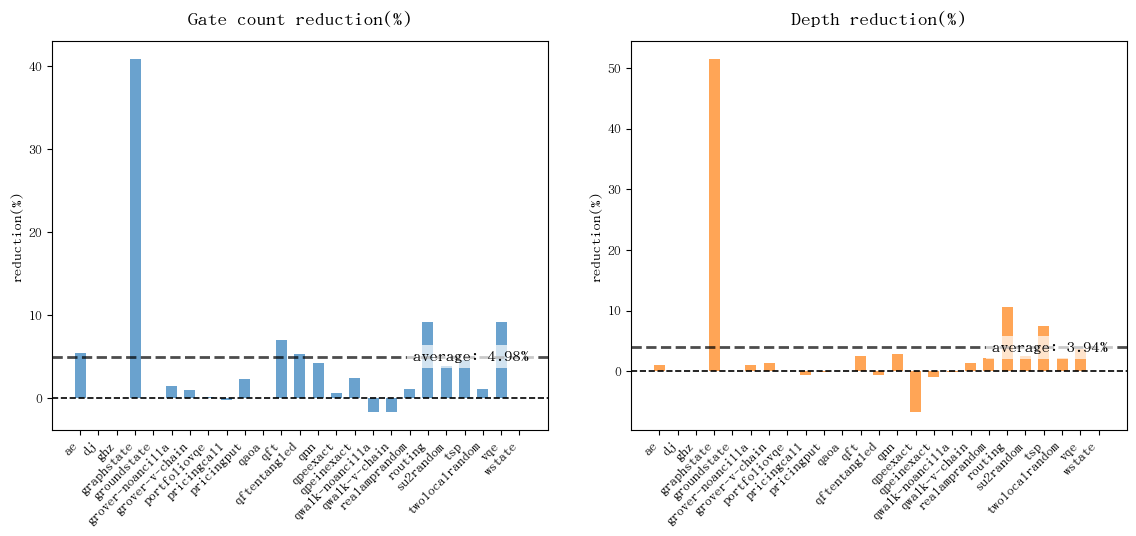

In [3]:
from utils.compare_data import compare_qasm_diff
from utils.show_data import show
qiskit_compiled_path = "./Qiskit"
qllvm_compiled_path = "./QLLVM" 
output_csv = "./result/qllvm_qiskit.csv"
compare_qasm_diff(qiskit_compiled_path,qllvm_compiled_path,output_csv)
show(output_csv)

（2）Comparison between QLLVM and Qpanda

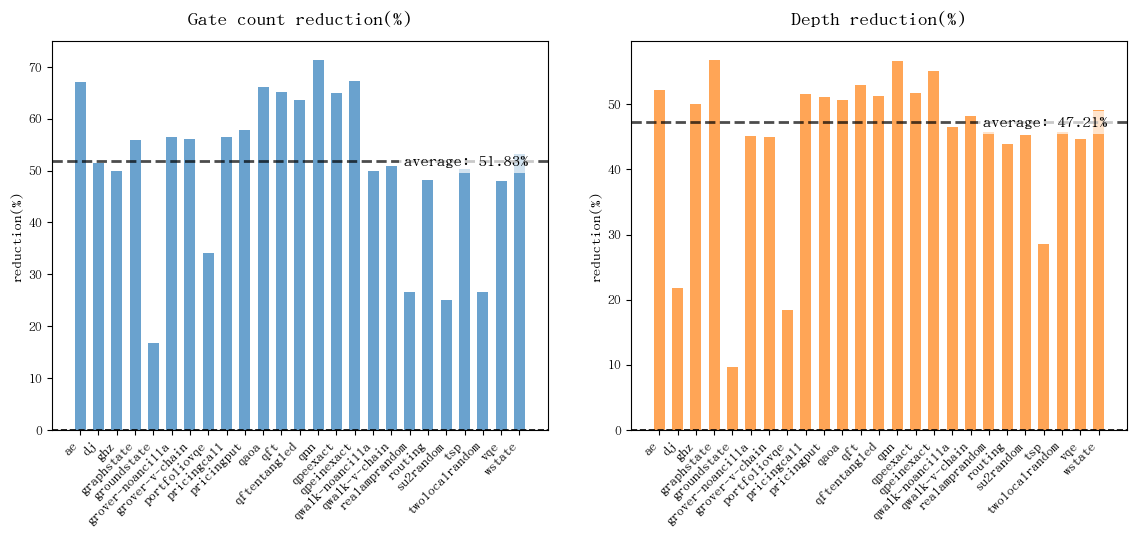

In [ ]:
from utils.compare_data import compare_qasm_diff
from utils.show_data import show
qpanda_compiled_path = "./Qpanda"
qllvm_compiled_path = "./QLLVM"
output_csv = "./result/qllvm_qpanda.csv"
compare_qasm_diff(qpanda_compiled_path,qllvm_compiled_path,output_csv)
show(output_csv)

（3）Comparison between QLLVM and PennyLane

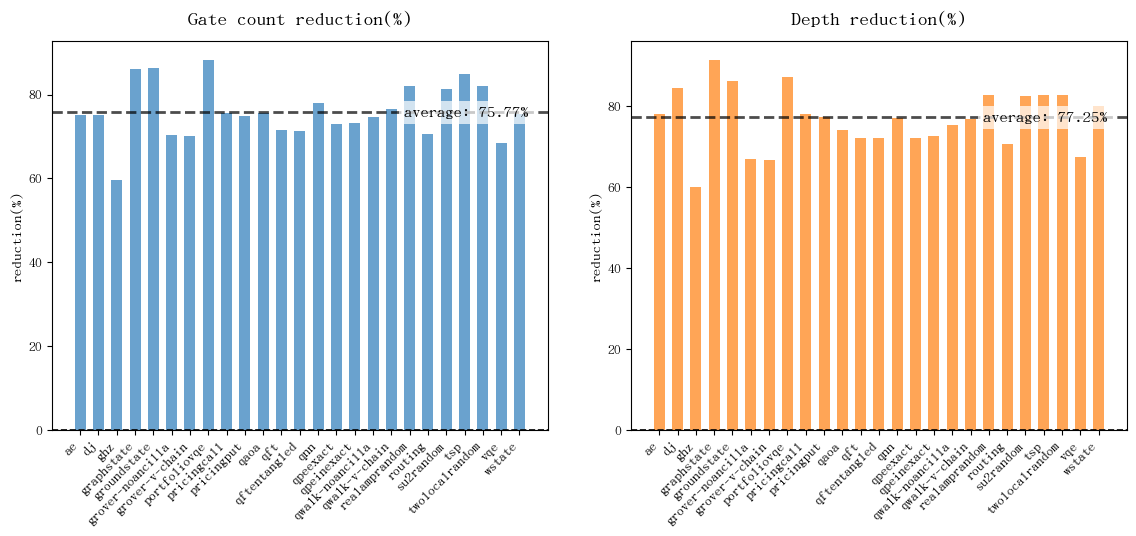

In [14]:
from utils.compare_data import compare_qasm_diff
from utils.show_data import show
pennylane_compiled_path = "./Pennylane"
qllvm_compiled_path = "./QLLVM"
output_csv = "./result/qllvm_pennylane.csv"
compare_qasm_diff(pennylane_compiled_path,qllvm_compiled_path,output_csv)
show(output_csv)